In [3]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2" 

import gc
import io
import pickle
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import rdata
import requests
import scanpy as sc
import scikit_posthocs as sp
import seaborn as sns
import torch
from scipy.stats import kruskal

sys.path.append('../scripts')

from ccc_pipeline import run_pipeline

warnings.filterwarnings('ignore')

# Cell-cell communication analysis

This notebook runs and summarizes a cell-cell communication analysis performed with LIANA and Tensor-cell2cell.

The goal is to identify communication programs that vary across PAM50 breast cancer subtypes and to determine which cell types and ligand-receptor interactions contribute most strongly to these subtype-associated patterns.

## Run LIANA + Tensor-cell2cell

This is a workflow to identify cell-cell communication programs associated with PAM50 subtypes, which consists of the following steps:

1. **LIANA inference per donor.**  
   LIANA was run with `donor_id` as the sample identifier, `cell_type_major` as the cell grouping variable, and the **consensus** resource for ligand-receptor inference. The parameters were `min_cells=20` and `expr_prop=0.2`. More information about `li.mt.rank_aggregate` can be found at [LIANA website](https://liana-py.readthedocs.io/en/latest/generated/liana.method.rank_aggregate.__call__.html).

2. **Subtype-level recurrence filter.**  
   For each PAM50 subtype, each `source-target-ligand-receptor` combination was retained only if it was detected in at least `min_donors_prop=0.4` of donors within that subtype.

3. **Tumor-microenvironment interaction filter.**  
   The analysis was restricted to `interaction_mode='t_nt,nt_t'`, i.e. tumor -> non-tumor and non-tumor -> tumor interactions. Tumor-tumor and non-tumor - non-tumor interactions were excluded.

4. **Tensor construction.**  
   The filtered LIANA output was converted into a 4D tensor with dimensions: **donors × ligand-receptor pairs × sender cells × receiver cells**. Tensor values were based on LIANA `magnitude_rank`, with missing entries filled by zero.

5. **Tensor-cell2cell decomposition.**  
   The communication tensor was decomposed into latent factors. Each factor is represented by four loading vectors: **contexts, ligand-receptor pairs, sender cells, and receiver cells**.

For validation, the pipeline was first run on a small subset containing two donors per PAM50 subtype. The full dataset was processed separately via CLI because of runtime.

This pipeline was adapted from the official LIANA × Tensor-cell2cell tutorial: [Intercellular Context Factorization with Tensor-cell2cell](https://liana-py.readthedocs.io/en/latest/notebooks/liana_c2c.html).

### Test run

To confirm that the pipeline completed successfully and produced the expected outputs.

Data:

In [52]:
adata = sc.read_h5ad('../data/data_with_pam50_subtypes_filt_donors_aggr_cell_types_hgnc.h5ad')

subtypes = ['Basal', 'ERBB2', 'LumA', 'LumB']
selected_donors = []

for st in subtypes:
    donors = (
        adata.obs.loc[adata.obs['PAM50_subtype'] == st, 'donor_id']
        .drop_duplicates()
        .head(2)
        .tolist()
    )
    selected_donors += donors

adata_sub = adata[adata.obs['donor_id'].isin(selected_donors)].copy()
adata_sub.write_h5ad('../data/data_with_pam50_subtypes_hgnc_test.h5ad')

In [53]:
del adata, adata_sub
gc.collect();

Run:

In [54]:
liana_res, context_df = run_pipeline(
    adata_path='../data/data_with_pam50_subtypes_hgnc_test.h5ad',
    outdir='../data/liana_tensor_cell2cell_result',
    min_cells=20,
    expr_prop=0.2,
    min_donors_prop=0.4,
    tumor_label='Malignant cell',
    subtype_col='PAM50_subtype',
    sample_col='donor_id',
    celltype_col='cell_type_major',
    interaction_mode='tt',
    use_gpu=False,
)


=== Starting CCC pipeline ===
Params for LIANA: min_cells=20, expr_prop=0.2
Filters: min_donors_prop=0.4, interaction_mode="tt"
Running LIANA


Now running: wu_natgen_CID45171: 100%|██████████| 8/8 [02:17<00:00, 17.13s/it]


Rows in full LIANA result: 48404
Rows after min-donors filter: 48404
Rows after interaction-mode filter: 552
Unique LR pairs: 293
Unique source-target-LR combinations: 293

Building a Tensor


100%|██████████| 8/8 [00:02<00:00,  3.74it/s]


Tensor shape: (8, 293, 1, 1)

Build Metadata

Running Tensor-cell2cell
Device: cpu
Running Elbow Analysis


100%|██████████| 20/20 [00:50<00:00,  2.52s/it]

The rank at the elbow is: 5
Running Tensor Factorization
Done


### Full run

Command to run the full analysis via the CLI:

```{bash}
python ccc_pipeline.py \
    --adata-path ../data/data_with_pam50_subtypes_filt_donors_aggr_cell_types_hgnc.h5ad \
    --outdir ../data/liana_tensor_cell2cell_result \
    --min-cells 20 \
    --expr-prop 0.2 \
    --min-donors-prop 0.4 \
    --tumor-label 'Malignant cell' \
    --subtype-col PAM50_subtype \
    --sample-col donor_id \
    --celltype-col cell_type_major \
    --interaction-mode 't_nt,nt_t' \
    --use-gpu
```

## Load results

*The full pipeline was run on a server with GPU support, whereas the downstream inspection in this notebook is performed on CPU.*

*Because the serialized tensor object contains PyTorch data structures, a small patch is needed to load the result safely in the current environment.*

In [4]:
_orig = torch.storage._load_from_bytes
torch.storage._load_from_bytes = lambda b: torch.load(io.BytesIO(b), map_location='cpu', weights_only=False)

tensor_file  = '../data/liana_tensor_cell2cell_result/tensor__mincell_20__exprprop_0p2__mindonorsprop_0p4__interactmode_t_nt+nt_t.pkl'

with open(tensor_file, 'rb') as f:
    tensor = pickle.load(f)

torch.storage._load_from_bytes = _orig

I0000 00:00:1779599666.525521  784517 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779599668.765296  784517 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [5]:
liana_file = '../data/liana_tensor_cell2cell_result/liana_res_filtered_by_t_nt+nt_t__mincell_20__exprprop_0p2__mindonorsprop_0p4__interactmode_t_nt+nt_t.csv'
tensor_meta_file = '../data/liana_tensor_cell2cell_result/tensor_meta__mincell_20__exprprop_0p2__mindonorsprop_0p4__interactmode_t_nt+nt_t.pkl'

liana_res = pd.read_csv(liana_file)
liana_res = liana_res[['donor_id', 'source', 'target', 'ligand_complex', 'receptor_complex', 'specificity_rank', 'magnitude_rank', 'PAM50_subtype']]

with open(tensor_meta_file, 'rb') as f:
    tensor_meta = pickle.load(f)

Tensor-cell2cell represents cell-cell communication data as a multi-dimensional tensor. In this analysis, the tensor has four dimensions:
- Contexts (donors),
- Ligand-receptor pairs,
- Sender cells,
- Receiver cells.

Tensor decomposition identifies **latent factors**, where each factor corresponds to a communication program captured across all four dimensions.

For each factor, Tensor-cell2cell returns four loading vectors: contexts, LR-pairs, senders, receivers.

The loading value reflects the contribution of a donor, ligand-receptor pair, sender cell type, or receiver cell type to that factor. Higher loadings indicate stronger association with the corresponding communication program.

In this report, factors are interpreted through:
- **context loadings**, to assess how factor activity differs across PAM50 subtypes;
- **cell-type and ligand-receptor loadings**, to identify the interactions driving each factor.

In [6]:
print('Detected factors:', tensor.rank)

Detected factors: 1


Only one factor was detected in this decomposition, which suggests that the variation in the communication can be summarized by a single latent program.

Compare donor loadings for this factor across PAM50 subtypes:

In [33]:
def run_kw_dunn(df, group_col, value_col, group_order, title):
    samples = [
        df.loc[df[group_col] == g, value_col].values
        for g in group_order
    ]
    h_stat, p_val = kruskal(*samples)

    print(f'Kruskal-Wallis for {title}:')
    print(f'H = {h_stat:.4f}, p = {p_val:.6g}')

    dunn = sp.posthoc_dunn(
        df,
        val_col=value_col,
        group_col=group_col,
        p_adjust='holm'
    )
    print(f'\nPost-hoc Dunns test for {title}')
    print(dunn.to_string(float_format='%.6f'))
    print()

    return p_val


context_loadings = tensor.factors['Contexts']
context_loadings['PAM50_subtype'] = context_loadings.index.to_series().map(
    liana_res.drop_duplicates('donor_id').set_index('donor_id')['PAM50_subtype']
)

subtype_order = ['Basal', 'ERBB2', 'LumA', 'LumB']
_ = run_kw_dunn(context_loadings, 'PAM50_subtype', 'Factor 1', subtype_order, 'donors loadings')

Kruskal-Wallis for donors loadings:
H = 12.9987, p = 0.00463938

Post-hoc Dunns test for donors loadings
         Basal    ERBB2     LumA     LumB
Basal 1.000000 0.526124 0.004117 0.029020
ERBB2 0.526124 1.000000 0.526124 0.714334
LumA  0.004117 0.526124 1.000000 0.714334
LumB  0.029020 0.714334 0.714334 1.000000



The subtype effect is statistically significant. Post-hoc Dunn's test identifies significant differences for:
- Basal vs LumA
- Basal vs LumB

## General tensor score

Because each factor is represented by four loading vectors, it is possible to assign a factor-derived score to every interaction reported by LIANA.

For a given donor-level interaction, the score is defined as the product of the corresponding loadings ($w$):

$score = w_{context} \cdot w_{sender} \cdot w_{receiver} \cdot w_{LRpair}$

For easier interpretation, this score is normalized to the interval (0, 1].

Unlike LIANA ranks, the Tensor-cell2cell score is not reversed:   higher values indicate stronger contribution to the inferred factor.

In [8]:
liana_res['lr_pair'] = liana_res['ligand_complex'] + '^' + liana_res['receptor_complex']

context_map = tensor.factors['Contexts']['Factor 1']
sender_map = tensor.factors['Sender Cells']['Factor 1']
receiver_map = tensor.factors['Receiver Cells']['Factor 1']
lr_map = tensor.factors['Ligand-Receptor Pairs']['Factor 1']

liana_res['tensor_score'] = (
    liana_res['donor_id'].map(context_map).to_numpy()
    * liana_res['source'].map(sender_map).to_numpy()
    * liana_res['target'].map(receiver_map).to_numpy()
    * liana_res['lr_pair'].map(lr_map).to_numpy()
)

liana_res['tensor_score_norm'] = liana_res['tensor_score'] / liana_res['tensor_score'].max()

liana_res.head(3)

,donor_id,source,target,ligand_complex,receptor_complex,specificity_rank,magnitude_rank,PAM50_subtype,lr_pair,tensor_score,tensor_score_norm
0,BC302_Tumor,Malignant cell,B_memory,COPA,CD74,0.043306,0.006429,ERBB2,COPA^CD74,0.000667,0.163369
1,BC302_Tumor,Malignant cell,Macrophage,COPA,CD74,0.043306,0.008716,ERBB2,COPA^CD74,0.000558,0.136606
2,BC302_Tumor,Malignant cell,Treg,COPA,CD74,0.178498,0.087625,ERBB2,COPA^CD74,0.000650,0.159250


## Filter cell-cell interactions

The LIANA run used the `consensus` resource, which is intentionally broad. This improves coverage but also introduces interactions with limited biological plausibility in this setting (e.g., HLA-A - ERBB2).

In [9]:
liana_res[(liana_res['ligand_complex'] == 'HLA-A') & (liana_res['receptor_complex'] == 'ERBB2')].sort_values('magnitude_rank', ascending=True).head(3)

,donor_id,source,target,ligand_complex,receptor_complex,specificity_rank,magnitude_rank,PAM50_subtype,lr_pair,tensor_score,tensor_score_norm
28731,pal_Patient 0031,Treg,Malignant cell,HLA-A,ERBB2,0.067010,0.000002,ERBB2,HLA-A^ERBB2,0.001679,0.411022
45104,wu_natgen_CID3921,Treg,Malignant cell,HLA-A,ERBB2,0.058729,0.000027,ERBB2,HLA-A^ERBB2,0.001729,0.423294
45105,wu_natgen_CID3921,Tfh,Malignant cell,HLA-A,ERBB2,0.065071,0.000047,ERBB2,HLA-A^ERBB2,0.000754,0.184513


To achieve a better balance between sensitivity and reliability, additional curation is needed. In practice, this means combining computational ranking with external evidence from curated interaction databases and the literature.

In this preliminary analysis, I use [CellChatDB](https://github.com/jinworks/CellChat), a curated database of cell-cell interactions, as an additional filter.  

This serves two purposes:
1. retain interactions with curated support;
2. assign pathway annotations where available.

Download the database:

In [10]:
url = 'https://raw.githubusercontent.com/jinworks/CellChat/main/data/CellChatDB.human.rda'
file = '../data/CellChatDB/CellChatDB.human.rda'

os.makedirs(os.path.dirname(file), exist_ok=True)

r = requests.get(url)
with open(file, 'wb') as f:
    f.write(r.content)

converted = rdata.conversion.convert(rdata.parser.parse_file(file))
obj = converted['CellChatDB.human']
cellchat_db = pd.DataFrame(obj['interaction'])

To ensure consistency, CellChat entries were reformatted to match LIANA's alphabetical ordering of complex subunits, and names were standardized (uppercase, formatting cleanup).

In [11]:
def canonicalize_complex(x):
    x = str(x).strip().upper().replace(' ', '')

    if '_' in x:
        parts = [p for p in x.split('_') if p]
        x = '_'.join(sorted(parts))

    return x

cellchat_db['ligand'] = cellchat_db['ligand'].apply(canonicalize_complex)
cellchat_db['receptor'] = cellchat_db['receptor'].apply(canonicalize_complex)
cellchat_db['lr_pair'] = cellchat_db['ligand'] + '^' + cellchat_db['receptor']

cellchat_db['pathway_name'] = cellchat_db['pathway_name'].astype(str).str.strip()
cellchat_db = cellchat_db[['lr_pair', 'pathway_name']]

cellchat_db.head(3)

,lr_pair,pathway_name
TGFB1_TGFBR1_TGFBR2,TGFB1^R2_TGFBR1,TGFb
TGFB2_TGFBR1_TGFBR2,TGFB2^R2_TGFBR1,TGFb
TGFB3_TGFBR1_TGFBR2,TGFB3^R2_TGFBR1,TGFb


The same normalization was applied to the LIANA output to enable a consistent merge.

In [ ]:
liana_res['ligand_complex'] = liana_res['ligand_complex'].apply(canonicalize_complex)
liana_res['receptor_complex'] = liana_res['receptor_complex'].apply(canonicalize_complex)
liana_res['lr_pair'] = liana_res['ligand_complex'] + '^' + liana_res['receptor_complex']

liana_res_annot = liana_res.merge(
    cellchat_db[['lr_pair', 'pathway_name']],
    on='lr_pair',
    how='left'
    )

liana_res_annot['pathway_name'] = liana_res_annot['pathway_name'].fillna('Unassigned')

n_total = len(liana_res_annot)
n_mapped = (liana_res_annot['pathway_name'] != 'Unassigned').sum()
print(f'Mapped to CellChat pathway_name: {n_mapped}/{n_total} ({n_mapped / n_total:.1%})')

liana_res_annot.sort_values('tensor_score_norm', ascending=False).head()

Mapped to CellChat pathway_name: 12101/55417 (21.8%)


,donor_id,source,target,ligand_complex,receptor_complex,specificity_rank,magnitude_rank,PAM50_subtype,lr_pair,tensor_score,tensor_score_norm,pathway_name
16164,BIOKEY_31,Malignant cell,Exhausted_T,B2M,KLRD1,1.000000,0.080610,Basal,B2M^KLRD1,0.004085,1.000000,Unassigned
16089,BIOKEY_31,Malignant cell,CD4_Tconv,MIF,CD74_CXCR4,0.171184,0.006858,Basal,MIF^CD74_CXCR4,0.003988,0.976361,MIF
16237,BIOKEY_31,Malignant cell,CD4_Tconv,HMGB1,CXCR4,0.377453,0.211511,Basal,HMGB1^CXCR4,0.003884,0.950919,Unassigned
16163,BIOKEY_31,Malignant cell,Exhausted_T,MIF,CD74_CXCR4,0.898562,0.079046,Basal,MIF^CD74_CXCR4,0.003794,0.928854,MIF
16172,BIOKEY_31,Malignant cell,NK,B2M,KLRD1,1.000000,0.089093,Basal,B2M^KLRD1,0.003790,0.927785,Unassigned


After matching LIANA interactions to CellChatDB, **21.8%** of interactions received a pathway annotation.

To assess whether excluding unassigned interactions would remove a large fraction of the strongest signals, let's inspect their prevalence and average tensor score:

In [13]:
unassigned_stats = (
    liana_res_annot[liana_res_annot['pathway_name'] == 'Unassigned']
    .groupby(['source', 'target', 'lr_pair'], as_index=False)
    .agg(
        mean_tensor_score_norm=('tensor_score_norm', 'mean'),
        donor_count=('donor_id', 'nunique')
    ))

display(unassigned_stats.sort_values(['donor_count'], ascending=[False]).head(3))
display(unassigned_stats.sort_values(['mean_tensor_score_norm'], ascending=[False]).head(3))

,source,target,lr_pair,mean_tensor_score_norm,donor_count
311,Fibroblast_Stromal,Malignant cell,TIMP1^CD63,0.249198,112
628,Malignant cell,Fibroblast_Stromal,CALR^LRP1,0.087467,108
281,Fibroblast_Stromal,Malignant cell,LUM^ITGB1,0.232923,107


,source,target,lr_pair,mean_tensor_score_norm,donor_count
585,Malignant cell,Exhausted_T,B2M^KLRD1,0.536228,41
425,Malignant cell,CD4_Tconv,HMGB1^CXCR4,0.495773,85
819,Malignant cell,NK,B2M^KLRD1,0.488087,90


The most common unassigned interactions are present across many donors, but their average normalized score is moderate. The strongest unassigned interactions reached higher scores, but they were generally less widespread.

Given this trade-off, excluding unassigned interactions appears acceptable for the preliminary analysis. Therefore, all interactions without CellChat annotation were removed from the downstream interpretation.

In [14]:
liana_res_annot = liana_res_annot.loc[liana_res_annot['pathway_name'] != 'Unassigned']

Among the annotated pathways, there were interactions labeled as `MHC-I` and `MHC-II` - corresponded to HLA molecules paired with co-receptors CD4 or CD8.

These pairs were excluded because their functional interpretation is not valid without information on the presented peptide and TCR specificity.

In [15]:
tcr_mhc_mask = (
    (liana_res_annot['ligand_complex'].str.startswith('HLA') &
     liana_res_annot['receptor_complex'].isin(['CD8A', 'CD8B']))
    |
    (liana_res_annot['ligand_complex'].str.startswith('HLA') &
     (liana_res_annot['receptor_complex'] == 'CD4'))
)

liana_res_annot = liana_res_annot[~tcr_mhc_mask]

## The most meaningful interactions

I next examined whether the tensor scores for filtered interactions differ across PAM50 subtypes.

Kruskal-Wallis for total score:
H = 40.1320, p = 9.99002e-09

Post-hoc Dunns test for total score
         Basal    ERBB2     LumA     LumB
Basal 1.000000 0.515141 0.000143 0.000000
ERBB2 0.515141 1.000000 0.010472 0.000134
LumA  0.000143 0.010472 1.000000 0.269507
LumB  0.000000 0.000134 0.269507 1.000000



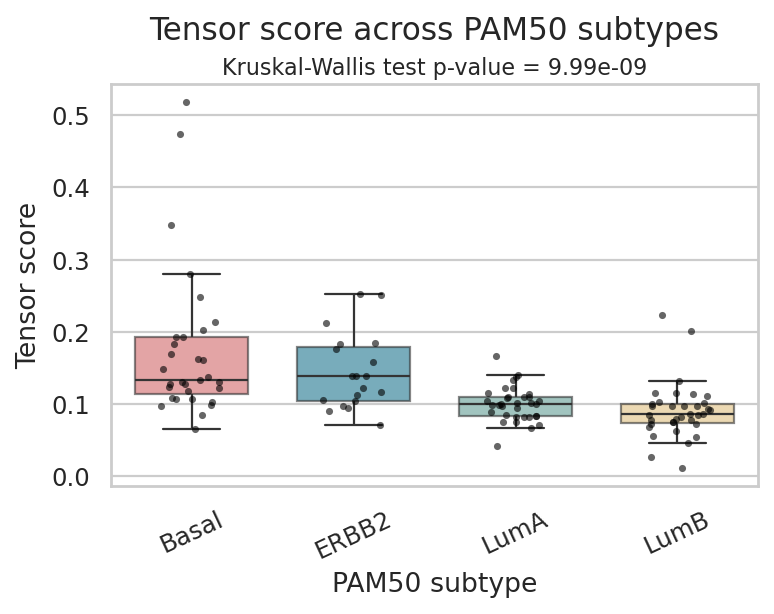

In [ ]:
total_score_by_donor = (
    liana_res_annot
    .groupby(['donor_id', 'PAM50_subtype'])['tensor_score_norm']
    .median()
    .reset_index(level='PAM50_subtype')
)

subtype_order = ['Basal', 'ERBB2', 'LumA', 'LumB']
p_val = run_kw_dunn(total_score_by_donor, 'PAM50_subtype', 'tensor_score_norm', subtype_order, 'total score')

subtitle = f'Kruskal-Wallis test p-value = {p_val:.2e}'

palette = {
    'Basal': '#e25759',
    'ERBB2':'#0b81a2',
    'LumB': '#f0c571',
    'LumA': '#59a89c',
}

sns.set_theme(style='whitegrid')

fig, ax = plt.subplots(figsize=(5, 4), dpi=160)

sns.boxplot(
    data=total_score_by_donor,
    x='PAM50_subtype', y='tensor_score_norm',
    order=subtype_order,
    palette=palette,
    width=0.7,
    showfliers=False,
    linewidth=1.0,
    boxprops={'alpha': 0.6},
    ax=ax
)

sns.stripplot(
    data=total_score_by_donor,
    x='PAM50_subtype', y='tensor_score_norm',
    order=subtype_order,
    color='black',
    jitter=0.2,
    size=3.2,
    alpha=0.6,
    ax=ax
)

ax.set_title('Tensor score across PAM50 subtypes', fontsize=14, pad=20)
ax.text(
    0.5, 1.01, subtitle,
    transform=ax.transAxes,
    ha='center', va='bottom',
    fontsize=10
)

ax.set_xlabel('PAM50 subtype', fontsize=12)
ax.set_ylabel('Tensor score', fontsize=12)
ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

The subtype effect is highly significant. The post-hoc comparisons show that the inferred communication program is more strongly expressed in *Basal-like and ERBB2+* than in *Luminal A and Liminal B*.

### Direction-specific analysis

To understand where this subtype-associated signal is strongest, I split the interactions into two directions:

- **TME -> Tumor**
- **Tumor -> TME**

This makes it possible to distinguish signals coming from TME and acting on malignant cells from signals produced by malignant cells and received by TME.

In [17]:
tme_to_tumor = liana_res_annot[
    (liana_res_annot['source'] != 'Malignant cell') &
    (liana_res_annot['target'] == 'Malignant cell')
].copy()

tumor_to_tme = liana_res_annot[
    (liana_res_annot['source'] == 'Malignant cell') &
    (liana_res_annot['target'] != 'Malignant cell')
].copy()

Kruskal-Wallis for TME -> Tumor:
H = 33.1460, p = 3.00022e-07

Post-hoc Dunns test for TME -> Tumor
         Basal    ERBB2     LumA     LumB
Basal 1.000000 0.677567 0.003323 0.000002
ERBB2 0.677567 1.000000 0.037542 0.000233
LumA  0.003323 0.037542 1.000000 0.129187
LumB  0.000002 0.000233 0.129187 1.000000

Kruskal-Wallis for Tumor -> TME:
H = 48.3170, p = 1.82308e-10

Post-hoc Dunns test for Tumor -> TME
         Basal    ERBB2     LumA     LumB
Basal 1.000000 0.148569 0.002239 0.000001
ERBB2 0.148569 1.000000 0.000041 0.000000
LumA  0.002239 0.000041 1.000000 0.122379
LumB  0.000001 0.000000 0.122379 1.000000



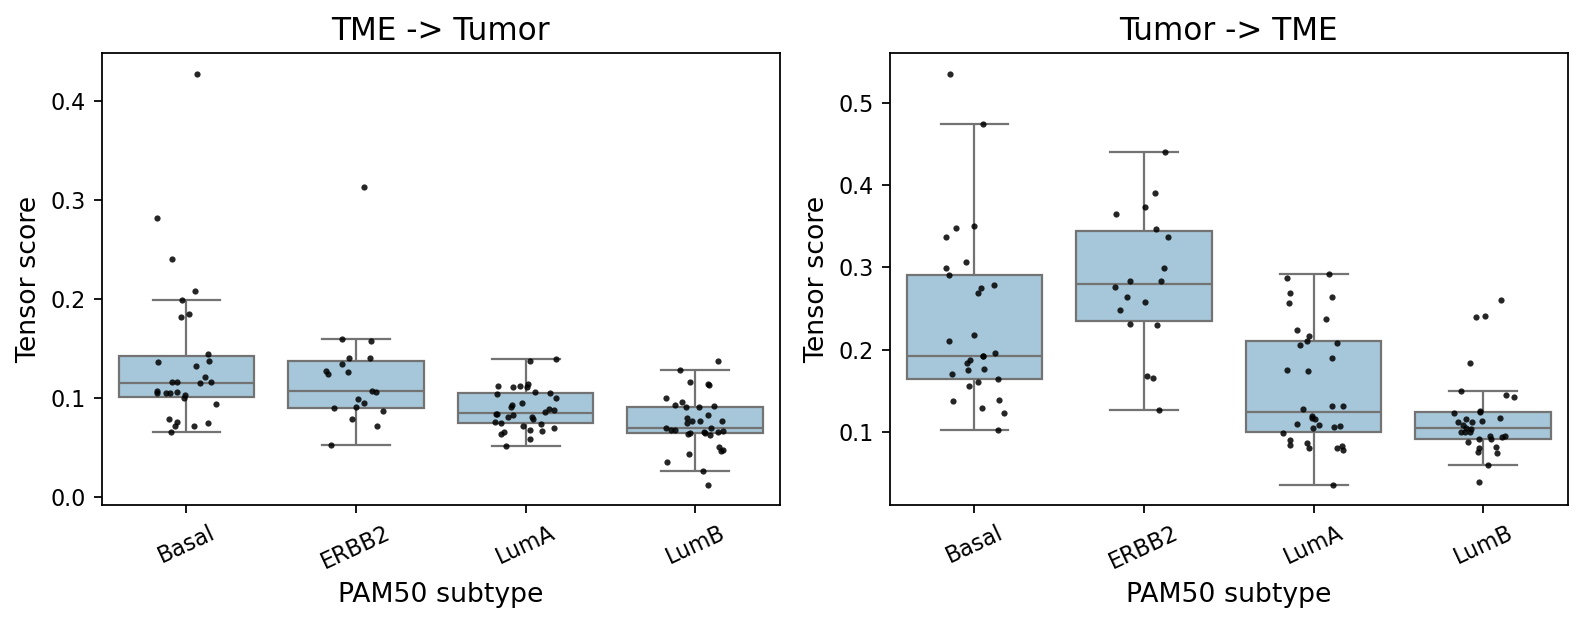

In [ ]:
subtype_order = ['Basal', 'ERBB2', 'LumA', 'LumB']

tme_to_tumor_score = (
    tme_to_tumor
    .groupby(['donor_id', 'PAM50_subtype'])['tensor_score_norm']
    .median()
    .reset_index(level='PAM50_subtype')
)

tumor_to_tme_score = (
    tumor_to_tme
    .groupby(['donor_id', 'PAM50_subtype'])['tensor_score_norm']
    .median()
    .reset_index(level='PAM50_subtype')
)

subtype_order = ['Basal', 'ERBB2', 'LumA', 'LumB']

_ = run_kw_dunn(tme_to_tumor_score, 'PAM50_subtype', 'tensor_score_norm', subtype_order, 'TME -> Tumor')
_ = run_kw_dunn(tumor_to_tme_score, 'PAM50_subtype', 'tensor_score_norm', subtype_order, 'Tumor -> TME')

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=160, sharey=False)

sns.boxplot(
    data=tme_to_tumor_score, x='PAM50_subtype', y='tensor_score_norm',
    order=subtype_order, color='#9ecae1', showfliers=False,
    linewidth=1.0, ax=axes[0]
)
sns.stripplot(
    data=tme_to_tumor_score, x='PAM50_subtype', y='tensor_score_norm',
    order=subtype_order, color='black',
    size=2.8, alpha=0.85, jitter=0.18, ax=axes[0]
)
axes[0].set_title('TME -> Tumor', fontsize=14)
axes[0].set_xlabel('PAM50 subtype', fontsize=12)
axes[0].set_ylabel('Tensor score', fontsize=12)
axes[0].tick_params(axis='x', rotation=25)

sns.boxplot(
    data=tumor_to_tme_score, x='PAM50_subtype', y='tensor_score_norm',
    order=subtype_order, color='#9ecae1', showfliers=False,
    linewidth=1.0, ax=axes[1]
)
sns.stripplot(
    data=tumor_to_tme_score, x='PAM50_subtype', y='tensor_score_norm',
    order=subtype_order, color='black',
    size=2.8, alpha=0.85, jitter=0.18, ax=axes[1]
)
axes[1].set_title('Tumor -> TME', fontsize=14)
axes[1].set_xlabel('PAM50 subtype', fontsize=12)
axes[1].set_ylabel('Tensor score', fontsize=12)
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

Both directions demonstrate a significant subtype effect, but the patterns are not identical.

#### TME -> Tumor

Let's look at which TME cell types contribute the most to signaling toward malignant cells:

In [19]:
tme_to_tumor.groupby('source')['tensor_score_norm'].sum().sort_values(ascending=False).head(10)

source
Fibroblast_Stromal    354.978216
Endothelial           132.927413
Mural                 116.691044
Macrophage             48.762893
Dendritic_cell         27.963378
Treg                    8.070784
NK                      7.711140
Plasma                  7.230824
CD8_T                   6.721481
CD4_Tconv               6.131844
Name: tensor_score_norm, dtype: float64

The largest total scores are contributed by:
- Fibroblast_Stromal,
- Endothelial,
- Mural.

This points to a predominantly **stromal** communication program acting on tumor cells.

For the three leading sender populations, the top interactions are dominated by:

In [20]:
top_pairs = []

tme_to_tumor_top_source = tme_to_tumor.groupby('source')['tensor_score_norm'].sum().sort_values(ascending=False).index[:3].to_list()
for source in tme_to_tumor_top_source:
    top3_pairs = (tme_to_tumor.loc[tme_to_tumor['source'] == source]
           .groupby(['lr_pair', 'pathway_name'])['tensor_score_norm']
           .sum()
           .sort_values(ascending=False)
           .head(3).reset_index()
           )

    print('\nCell type:', source)
    display(top3_pairs)

    top3_pairs['source'] = source
    top_pairs.append(top3_pairs[['source', 'lr_pair']])


Cell type: Fibroblast_Stromal


,lr_pair,pathway_name,tensor_score_norm
0,COL1A1^CD44,COLLAGEN,32.457468
1,APP^CD74,APP,30.707876
2,COL1A2^CD44,COLLAGEN,28.725854



Cell type: Endothelial


,lr_pair,pathway_name,tensor_score_norm
0,APP^CD74,APP,24.503222
1,FN1^CD44,FN1,11.564470
2,MIF^CD44_CD74,MIF,8.817096



Cell type: Mural


,lr_pair,pathway_name,tensor_score_norm
0,COL1A1^CD44,COLLAGEN,13.502675
1,COL1A2^CD44,COLLAGEN,12.123032
2,APP^CD74,APP,9.336389


Distribution across subtypes:

In [21]:
top_pairs_df = pd.concat(top_pairs)
tme_to_tumor_top = tme_to_tumor.merge(top_pairs_df,
                                      on=['source', 'lr_pair'],
                                      how='inner')

tme_to_tumor_top.groupby('PAM50_subtype')['tensor_score_norm'].median().to_frame().sort_values('tensor_score_norm', ascending=False)

,tensor_score_norm
PAM50_subtype,
Basal,0.350598
ERBB2,0.300839
LumB,0.268640
LumA,0.246363


The median score of these top TME -> Tumor interactions decreases in the order: **Basal -> ERBB2 -> LumB -> LumA**.

This ordering is consistent with the general decline in proliferative and aggressive tumor behavior from Basal-like to Luminal A breast cancer ([Nielsen et al., 2010](https://doi.org/10.1158/1078-0432.CCR-10-1282))

A stronger stromal contribution in Basal-like tumors is biologically plausible, as these tumors are typically associated with more active stromal remodeling and a more reactive TME. By contrast, Luminal A tumors usually have the lowest proliferative activity and may require less intensive stromal support.

#### Tumor -> TME

Let's examine which TME cell types receive the strongest signals from malignant cells:

In [22]:
tumor_to_tme.groupby('target')['tensor_score_norm'].sum().sort_values(ascending=False).head(10)

target
Macrophage            126.390190
Dendritic_cell        110.660413
Treg                  101.869201
NK                    100.709097
CD8_T                  95.785786
CD4_Tconv              85.468777
B_memory               66.204389
Fibroblast_Stromal     55.292680
Naive_T                51.012329
Endothelial            47.627313
Name: tensor_score_norm, dtype: float64

The highest total scores were observed for:
- Macrophage,
- Dendritic_cell,
- Treg,
- NK.

Compared with the TME -> Tumor direction, this pattern is more clearly centered on **immune cell** targets.

It is also notable that the top score in this direction is almost 3 times lower than the leading stromal score in the opposite direction, suggesting that the stromal-to-tumor axis is the quantitatively stronger component of the factor.

For the four leading sender populations, the top interactions are dominated by:

In [23]:
top_pairs = []

tumor_to_tme_top_target = tumor_to_tme.groupby('target')['tensor_score_norm'].sum().sort_values(ascending=False).index[:4].to_list()
for target in tumor_to_tme_top_target:
    top3_pairs = (tumor_to_tme.loc[tumor_to_tme['target'] == target]
           .groupby(['lr_pair', 'pathway_name'])['tensor_score_norm']
           .sum()
           .sort_values(ascending=False)
           .head(3).reset_index()
           )

    print('\nCell type:', target)
    display(top3_pairs)

    top3_pairs['target'] = target
    top_pairs.append(top3_pairs[['target', 'lr_pair']])


Cell type: Macrophage


,lr_pair,pathway_name,tensor_score_norm
0,APP^CD74,APP,32.816211
1,MIF^CD74_CXCR4,MIF,32.804801
2,MIF^CD44_CD74,MIF,24.960932



Cell type: Dendritic_cell


,lr_pair,pathway_name,tensor_score_norm
0,MIF^CD74_CXCR4,MIF,32.707269
1,APP^CD74,APP,29.624012
2,MIF^CD44_CD74,MIF,22.342145



Cell type: Treg


,lr_pair,pathway_name,tensor_score_norm
0,MIF^CD74_CXCR4,MIF,35.837399
1,APP^CD74,APP,30.914252
2,MIF^CD44_CD74,MIF,23.457664



Cell type: NK


,lr_pair,pathway_name,tensor_score_norm
0,MIF^CD74_CXCR4,MIF,32.307495
1,APP^CD74,APP,28.111278
2,MIF^CD44_CD74,MIF,22.344777


Distribution across subtypes:

In [24]:
top_pairs_df = pd.concat(top_pairs)
tumor_to_tme_top = tumor_to_tme.merge(top_pairs_df,
                                      on=['target', 'lr_pair'],
                                      how='inner')

tumor_to_tme_top.groupby('PAM50_subtype')['tensor_score_norm'].median().to_frame().sort_values('tensor_score_norm', ascending=False)

,tensor_score_norm
PAM50_subtype,
Basal,0.418395
ERBB2,0.367014
LumA,0.312588
LumB,0.311830


These top Tumor -> TME interactions again show the highest median scores in Basal and ERBB2 with lower values in the Luminal subtypes.

Thus, the leading tumor-derived communication signals follow the same subtype trend as the broader factor.

## Summary

This preliminary analysis identifies a communication program combining **stromal remodeling** and **immune-modulatory signaling**. The program is more active in **Basal-like** and **ERBB2+** tumors and weaker in **Luminal A/B** tumors.

1. The TME -> tumor direction is dominated by stromal populations: Fibroblast/Stromal, Endothelial, and Mural cells.

The leading interactions include:
- COL1A1 ^ CD44, 
- COL1A2 ^ CD44,
- FN1 ^ CD44,
- MIF ^ CD44_CD74.

This axis is consistent with extracellular matrix remodeling, adhesion, and a more reactive stromal niche.

2. The Tumor -> TME direction is centered on communication from malignant cells to immune populations: Macrophage, Dendritic cells, Treg, NK cells.

The dominant interactions include:
- APP ^ CD74,
- MIF ^ CD74_CXCR4, 
- MIF ^ CD44_CD74.

This pattern is consistent with an immune-regulatory or immunosuppressive signaling program.

**Biological interpretation**

Several of the highlighted molecules are well established in tumor biology:

- **COL1A1 and COL1A2:** secrection of collagen Cancer-Associated Fibroblasts (CAF) is linked to cancer invasion and metastasis ([Li et al., 2020](https://www.sciencedirect.com/science/article/pii/S0014482720304006)). 

- **FN1:** fibronectin 1 is associated to tumor cell prolifiration and migration ([Li et al., 2019](https://pmc.ncbi.nlm.nih.gov/articles/PMC6503329/)).

**MIF:** macrophage migration inhibitory factor is a pleiotropic cytokine implicated in proliferation, survival, angiogenesis, immune evasion, and therapy resistance ([Youness et al., 2025](https://doi.org/10.3389/fimmu.2025.1636839)).

**CD44** supports tumor progression by mediating TME interactions: it promotes cell adhesion and migration (facilitating invasion/metastasis), contributes to pro-tumor signaling and angiogenesis ([Griffioen et al., 1997](https://www.sciencedirect.com/science/article/pii/S0006497120581299)).

**APP-CD74:** is associated with immunosuppressive subsets of tumor-associated macrophages (TAMs) and promotes their polarization toward an M2-like state, reinforcing an immunosuppressive TME [Chen et al., 2026](https://pubmed.ncbi.nlm.nih.gov/41882095/).

---

**Limitation**

A key limitation of this workflow is that many inferred interactions were excluded because they could not be confidently annotated. 

While this improves interpretability, it also reduces coverage and may remove biologically relevant, breast cancer-specific signals.

A more complete follow-up analysis would combine curated databases with targeted literature review to retain additional high-confidence interactions and refine the biological interpretation.